# Adaptive Beamforming by Deep Learning (ABLE)

Delay-and-sum adds up the time-of-flight corrected channel signals with fixed apodization weights. Adaptive beamformers instead derive the weights per pixel from the data itself, which suppresses off-axis clutter and sharpens the image. The classic example is [minimum variance](../../_autosummary/zea.ops.rst#zea.ops.MinimumVariance) beamforming, and it is expensive: it estimates and inverts a covariance matrix for every single pixel.

[ABLE](../../_autosummary/zea.models.able.rst#zea.models.able.ABLE) (Adaptive Beamforming by deep LEarning) keeps the adaptive weights but replaces that estimator with a small neural network, which predicts the weights directly from the delayed channel data. Trained to imitate an adaptive beamformer, it approaches its image quality at close to delay-and-sum cost.

In this notebook we beamform a plane wave acquisition three ways: delay-and-sum, minimum variance, and an ABLE model that we train — inside the pipeline — to mimic minimum variance.

Reference: Luijten et al., "Adaptive Ultrasound Beamforming Using Deep Learning", *IEEE Transactions on Medical Imaging* **39** (12), 2020.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/models/adaptive_beamforming_by_deep_learning.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/models/adaptive_beamforming_by_deep_learning.ipynb)
&nbsp;
[![Hugging Face dataset](https://img.shields.io/badge/Hugging%20Face-Dataset-yellow?logo=huggingface)](https://huggingface.co/datasets/zeahub/picmus)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [3]:
import keras
import matplotlib.pyplot as plt
import numpy as np

import zea
from zea import init_device
from zea.display import histogram_match, to_8bit
from zea.models.able import ABLE
from zea.ops import Beamform, EnvelopeDetect, LogCompress, Normalize, Pipeline
from zea.utils import FunctionTimer
from zea.visualize import set_mpl_style

zea: Using backend 'jax'


In [4]:
init_device(verbose=False)
set_mpl_style()

In [5]:
# Cost knobs. The notebook test overrides these to keep CI quick, see
# NOTEBOOK_PARAMETERS in tests/test_notebooks.py.
#
# Training from a random init is not perfectly reliable here: at 1e-3 roughly one seed in
# three stalls near its starting loss. At 1e-2 every seed tried converged, the loss
# flattening out somewhere between step 700 and 1000 -- the spread is real, since the
# GPU reductions are not bit-reproducible even with the seed fixed. 1200 leaves margin.
seed = 0
n_steps = 1200
learning_rate = 1e-2
num_patches = 100  # beamform the grid patch by patch; more patches is less peak memory
grid_size_z = None  # None lets zea size the grid at about half a wavelength
grid_size_x = None

## Loading data

We use a single plane wave acquisition from the [PICMUS](https://www.creatis.insa-lyon.fr/Challenge/IEEE_IUS_2016/home) dataset, hosted in zea format on the [Hugging Face Hub](https://huggingface.co/zeahub). A single transmit gives up little to compounding, which is exactly where an adaptive receive aperture has the most to offer.

In [6]:
path = (
    "hf://zeahub/picmus/database/experiments/contrast_speckle/"
    "contrast_speckle_expe_dataset_iq/contrast_speckle_expe_dataset_iq.hdf5"
)

with zea.File(path) as f:
    data = f.data.raw_data[0][None]  # first frame, with a batch dimension
    parameters = f.load_parameters()

parameters.set_transmits(1)  # a single, unsteered plane wave
data = data[:, parameters.selected_transmits]

parameters.xlims = (-0.019, 0.019)
parameters.zlims = (0.0, 0.06)

if grid_size_z is not None:
    parameters.grid_size_z = grid_size_z
if grid_size_x is not None:
    parameters.grid_size_x = grid_size_x

# Switch off the f-number mask, for all three beamformers, so they see the same
# aperture and the differences below are the beamformer's doing. Minimum variance in
# particular needs it: the mask zeroes receive channels, and those dead channels span a
# null space of the covariance that the loaded inverse fills with weight, starving the
# live ones and darkening the near field. An adaptive beamformer shapes its own aperture.
parameters.f_number = 0

## Beamforming with `zea.ops.Beamform`

[Beamform](../../_autosummary/zea.ops.rst#zea.ops.Beamform) is a pipeline that time-of-flight corrects the channel data and hands it to a beamformer of choice. Swapping the beamformer is a single keyword, so the same B-mode pipeline serves all three variants. Keywords the beamformer itself takes are forwarded to it, which is how minimum variance gets its sub-aperture length below: a shorter sub-aperture keeps the covariance better conditioned, and its inverse a good deal cheaper.

In [7]:
DYNAMIC_RANGE = (-60.0, 0.0)


def bmode_pipeline(beamformer, jit_options="ops", **kwargs):
    """B-mode pipeline: beamform, then envelope detect, normalize and log compress."""
    return Pipeline(
        operations=[
            Beamform(beamformer=beamformer, num_patches=num_patches, **kwargs),
            EnvelopeDetect(),
            Normalize(),
            LogCompress(),
        ],
        with_batch_dim=True,
        jit_options=jit_options,
    )

The pipeline is stateless: all acquisition parameters travel along with the data. We prepare them once and reuse them for every pipeline below.

In [8]:
das_pipeline = bmode_pipeline("delay_and_sum")
mv_pipeline = bmode_pipeline("minimum_variance", subarray_size=32)

inputs = das_pipeline.prepare_parameters(parameters)
inputs["dynamic_range"] = DYNAMIC_RANGE

das_bmode = das_pipeline(**inputs, data=data)["data"]
mv_bmode = mv_pipeline(**inputs, data=data)["data"]

Minimum variance narrows the point targets and cleans up the background, at the cost of a much heavier computation. That is the image we will ask ABLE to reproduce.

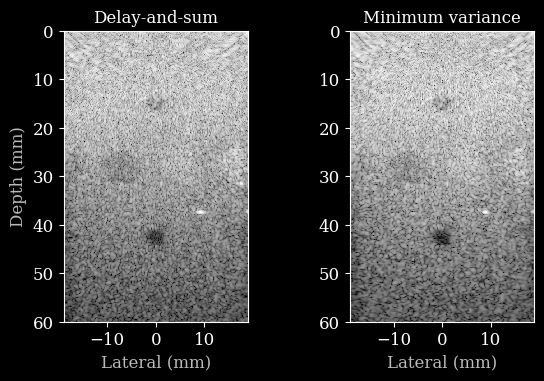

In [9]:
extent_mm = [
    parameters.xlims[0] * 1e3,
    parameters.xlims[1] * 1e3,
    parameters.zlims[1] * 1e3,
    parameters.zlims[0] * 1e3,
]


def plot_bmodes(images, titles):
    """Plot a row of B-mode images on a shared dynamic range.

    The panels are kept modest in size on purpose: speckle is noise-like and so compresses
    poorly, and the docs checker caps a single embedded output at 400 kB.
    """
    fig, axes = plt.subplots(
        1, len(images), figsize=(2.9 * len(images), 3.7), constrained_layout=True
    )
    for ax, image, title in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(to_8bit(np.array(image), DYNAMIC_RANGE), cmap="gray", extent=extent_mm)
        ax.set_title(title)
        ax.set_xlabel("Lateral (mm)")
    np.atleast_1d(axes)[0].set_ylabel("Depth (mm)")
    return fig


_ = plot_bmodes([das_bmode[0], mv_bmode[0]], ["Delay-and-sum", "Minimum variance"])

## The ABLE model

ABLE looks at the time-of-flight corrected samples of one pixel across the receive elements and predicts an apodization weight for each of them. Because every pixel is treated on its own, the network is a stack of 1×1 convolutions, kept small on purpose: a few thousand parameters is enough.

The model has to be built before it enters the pipeline, so that its weights are created eagerly rather than inside a traced pipeline call.

In [10]:
n_el, n_ch = data.shape[-2], data.shape[-1]

keras.utils.set_random_seed(seed)  # same starting point on every run
able = ABLE(latent_dim=32, n_latent_layers=2)
able.build((1, 1, n_el, n_ch))  # (n_tx, n_pix, n_el, n_ch)

able.summary()

Model: "able"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 1, 1, 256)         │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 1, 1, 32)          │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 1, 1, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 1, 1, 256)         │        16,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,928 (394.25 KB)

 Trainable params: 100,928 (394.25 KB)

 Non-trainable params: 0 (0.00 B)

ABLE is registered as a beamformer, so it slots into the very same pipeline. The one difference is `jit_options=None`: compiling the operations separately would cut the gradient path to the model weights, and training would silently stall.

In [11]:
able_pipeline = bmode_pipeline("able", model=able, jit_options=None)

## Training

ABLE is trained by regression: the whole pipeline is differentiable, so we can push the log-compressed image through it and compare it against the minimum variance image with a mean squared error. Gradients flow all the way back through the delay-and-sum and the envelope detection into the network weights.

Note that we are training on a single frame here — enough to make the point in a notebook. See the paper for the training regime used in practice.

In [12]:
class ABLEBeamformer(keras.Model):
    """Thin Keras model around the pipeline, exposing the ABLE weights to the optimizer."""

    def __init__(self, model, pipeline, parameters):
        super().__init__()
        self.able = model
        self.pipeline = pipeline
        self.parameters = parameters

    def call(self, data):
        return self.pipeline(**self.parameters, data=data)[self.pipeline.output_key]


trainer = ABLEBeamformer(able, able_pipeline, inputs)
trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")

In [13]:
losses = []
for step in range(1, n_steps + 1):
    loss = float(trainer.train_on_batch(data, mv_bmode))
    losses.append(loss)
    if step % 50 == 0:
        print(f"step {step:3d}/{n_steps}  loss {loss:.3f}")

step  50/1200  loss 58.463


step 100/1200  loss 49.384


step 150/1200  loss 42.850


step 200/1200  loss 41.830


step 250/1200  loss 36.805


...

step 1000/1200  loss 1.509


step 1050/1200  loss 1.507


step 1100/1200  loss 1.505


step 1150/1200  loss 1.504


step 1200/1200  loss 1.503


The loss should drop by more than an order of magnitude and then flatten out, which is what tells us the run has converged rather than simply run out of steps. If instead it hovers near where it started, that seed has stalled and the fix is to pick another one.

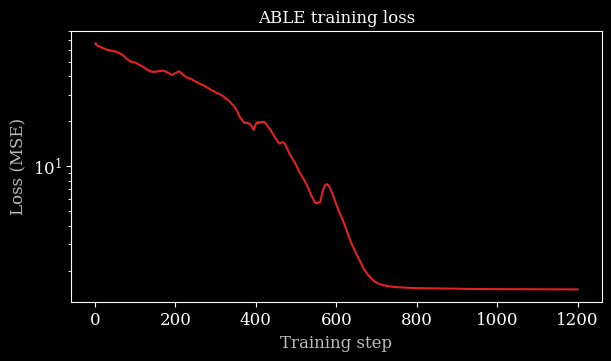

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
ax.plot(np.arange(1, len(losses) + 1), losses)
ax.set_yscale("log")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss (MSE)")
_ = ax.set_title("ABLE training loss")

## Results

Training is done, so we can hand the model to a compiled pipeline again and time all three beamformers. The first call of each is dropped, since it pays for tracing and compilation.

The three images are histogram matched to the delay-and-sum one before display, following [Bottenus et al.](https://doi.org/10.1109/TUFFC.2020.3035965): adaptive beamformers suppress off-axis energy, which shifts the brightness of the whole image, and without matching that shift reads as a difference in image quality.

In [15]:
trained_pipeline = bmode_pipeline("able", model=able)
able_bmode = trained_pipeline(**inputs, data=data)["data"]

timer = FunctionTimer()
timed = {
    name: timer(lambda p=pipeline: p(**inputs, data=data), name=name)
    for name, pipeline in [
        ("Delay-and-sum", das_pipeline),
        ("Minimum variance", mv_pipeline),
        ("ABLE", trained_pipeline),
    ]
}

for run in timed.values():
    for _ in range(6):  # one warmup + five timed runs
        run()

timer.print(drop_first=True)

Function Timing Statistics
Function              Mean          Median        Std Dev       Min           Max           Count    
-----------------------------------------------------------------------------------------------------
Delay-and-sum         0.002327      0.002342      0.000027      0.002291      0.002353      5        
Minimum variance      0.166709      0.165315      0.002508      0.165014      0.170872      5        
ABLE                  0.008633      0.008078      0.000781      0.008034      0.009507      5        


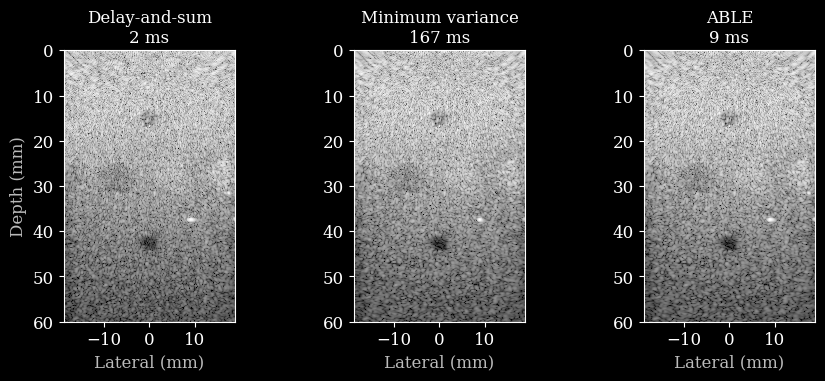

In [16]:
# Each beamformer compresses the dynamic range differently, which skews a
# side-by-side look. Matching all three to the delay-and-sum histogram puts them on a
# common scale, so what is left to see is the image and not the contrast.
reference = np.array(das_bmode[0])
matched = [
    histogram_match(np.array(image), reference)
    for image in (das_bmode[0], mv_bmode[0], able_bmode[0])
]

titles = [
    f"{name}\n{timer.get_stats(name, drop_first=True)['mean'] * 1e3:.0f} ms" for name in timed
]

_ = plot_bmodes(matched, titles)

ABLE recovers most of what minimum variance offers over delay-and-sum, at a fraction of its runtime — the covariance inversion is gone, replaced by a handful of 1×1 convolutions.

A few things to try from here:

- Train against another beamformer by changing a single word: `"coherence_factor"`, `"generalized_coherence_factor"` or `"delay_multiply_and_sum"` are all registered too.
- Train on more frames, or on a whole dataset with a [Dataloader](../../_autosummary/zea.data.dataloader.rst), which is what makes the model generalize beyond the frame shown here.
- Save the trained weights with `able.save_to_preset(...)` and reload them later with `ABLE.from_preset(...)`.